# MMGTFFF - Preprocessing Pipeline v2
## Multi-Modal Graph Transformer for Federated Financial Forecasting
---
**What this notebook does:**
1. Clones raw StockNet (88 tickers, prices + tweets, 2014-2016)
2. Processes raw prices → returns + technical indicators + target labels
3. Splits tweets into **Company** (node features) vs **Event/Global** (edge modifier)
4. Merges everything, trims to tweet window, fixes sector mapping
5. Saves clean outputs for FinBERT + SEC EDGAR + graph construction

## 1. Setup & Clone

In [1]:
!git clone https://github.com/yumoxu/stocknet-dataset.git
print('Cloned!')

Cloning into 'stocknet-dataset'...
remote: Enumerating objects: 53785, done.
remote: Total 53785 (delta 0), reused 0 (delta 0), pack-reused 53785 (from 1)
Receiving objects: 100% (53785/53785), 66.95 MiB | 17.97 MiB/s, done.
Resolving deltas: 100% (28658/28658), done.
Updating files: 100% (55141/55141), done.
Cloned!


In [2]:
import pandas as pd
import numpy as np
import json
import os
from datetime import datetime
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

PRICE_RAW = 'stocknet-dataset/price/raw/'
TWEET_PREPROCESSED = 'stocknet-dataset/tweet/preprocessed/'

price_tickers = sorted([f.replace('.csv','') for f in os.listdir(PRICE_RAW) if f.endswith('.csv')])
tweet_tickers = sorted([d for d in os.listdir(TWEET_PREPROCESSED) if os.path.isdir(os.path.join(TWEET_PREPROCESSED, d))])

print(f'Price tickers: {len(price_tickers)}')
print(f'Tweet tickers: {len(tweet_tickers)}')
print(f'Tickers: {price_tickers}')

Price tickers: 88
Tweet tickers: 87
Tickers: ['AAPL', 'ABB', 'ABBV', 'AEP', 'AGFS', 'AMGN', 'AMZN', 'BA', 'BABA', 'BAC', 'BBL', 'BCH', 'BHP', 'BP', 'BRK-A', 'BSAC', 'BUD', 'C', 'CAT', 'CELG', 'CHL', 'CHTR', 'CMCSA', 'CODI', 'CSCO', 'CVX', 'D', 'DHR', 'DIS', 'DUK', 'EXC', 'FB', 'GD', 'GE', 'GMRE', 'GOOG', 'HD', 'HON', 'HRG', 'HSBC', 'IEP', 'INTC', 'JNJ', 'JPM', 'KO', 'LMT', 'MA', 'MCD', 'MDT', 'MMM', 'MO', 'MRK', 'MSFT', 'NEE', 'NGG', 'NVS', 'ORCL', 'PCG', 'PCLN', 'PEP', 'PFE', 'PG', 'PICO', 'PM', 'PPL', 'PTR', 'RDS-B', 'REX', 'SLB', 'SNP', 'SNY', 'SO', 'SPLP', 'SRE', 'T', 'TM', 'TOT', 'TSM', 'UL', 'UN', 'UNH', 'UPS', 'UTX', 'V', 'VZ', 'WFC', 'WMT', 'XOM']


## 2. Sector Mapping
Every ticker gets a sector label. These become federated clients later.

In [3]:
# Print the actual StockTable from the repo to verify
!cat stocknet-dataset/StockTable

Sector	Symbol	Company
Basic Matierials	$XOM	Exxon Mobil Corporation
Basic Matierials	$RDS-B	Royal Dutch Shell
Basic Matierials	$PTR	PetroChina Company Limited
Basic Matierials	$CVX	Chevron Corporation
Basic Matierials	$TOT	TOTAL S.A.
Basic Matierials	$BP	BP p.l.c.
Basic Matierials	$BHP	BHP Billiton Limited
Basic Matierials	$SNP	China Petroleum & Corporation
Basic Matierials	$SLB	Schlumberger Limited
Basic Matierials	$BBL	BHP Billiton plc
Consumer Goods	$AAPL	Apple Inc.
Consumer Goods	$PG	The Procter & Gamble
Consumer Goods	$BUD	Anheuser-Busch InBev SA/NV Company
Consumer Goods	$KO	The Coca-Cola Company
Consumer Goods	$PM	Philip Morris International
Consumer Goods	$TM	Toyota Motor Corporation
Consumer Goods	$PEP	Pepsico  Inc.
Consumer Goods	$UN	Unilever N.V.
Consumer Goods	$UL	Unilever PLC
Consumer Goods	$MO	Altria Group Inc.
Healthcare	$JNJ	Johnson & Johnson
Healthcare	$PFE	Pfizer Inc.
Healthcare	$NVS	Novartis AG
Healthcare	$UNH	UnitedHealth Group Incorporated 
Healthcare	$MRK	Merck & 

In [4]:
# Full sector mapping for all 88 tickers
# Based on StockNet paper's 9 sectors + standard GICS for international stocks

SECTOR_MAP = {
    # Basic Materials
    'BHP': 'Basic_Materials', 'BBL': 'Basic_Materials', 'CLF': 'Basic_Materials',
    'FCX': 'Basic_Materials', 'NEM': 'Basic_Materials', 'NUE': 'Basic_Materials',
    'RIO': 'Basic_Materials', 'VALE': 'Basic_Materials', 'SCCO': 'Basic_Materials',
    'GOLD': 'Basic_Materials', 'SLB': 'Basic_Materials',
    'CVX': 'Basic_Materials', 'XOM': 'Basic_Materials', 'BP': 'Basic_Materials',
    'RDS-B': 'Basic_Materials', 'TOT': 'Basic_Materials', 'PTR': 'Basic_Materials',
    'SNP': 'Basic_Materials',
    # Conglomerates
    'MMM': 'Conglomerates', 'GE': 'Conglomerates', 'HON': 'Conglomerates',
    'ITW': 'Conglomerates', 'LMT': 'Conglomerates', 'TEL': 'Conglomerates',
    'TXT': 'Conglomerates', 'DHR': 'Conglomerates',
    'ABB': 'Conglomerates', 'IEP': 'Conglomerates', 'HRG': 'Conglomerates',
    'CODI': 'Conglomerates', 'PICO': 'Conglomerates', 'SPLP': 'Conglomerates',
    'REX': 'Conglomerates', 'AGFS': 'Conglomerates',
    # Consumer Goods
    'AAPL': 'Consumer_Goods', 'CLX': 'Consumer_Goods', 'CHD': 'Consumer_Goods',
    'CL': 'Consumer_Goods', 'EL': 'Consumer_Goods', 'GIS': 'Consumer_Goods',
    'HSY': 'Consumer_Goods', 'HRL': 'Consumer_Goods', 'SJM': 'Consumer_Goods',
    'MKC': 'Consumer_Goods', 'KO': 'Consumer_Goods', 'PEP': 'Consumer_Goods',
    'PG': 'Consumer_Goods', 'PM': 'Consumer_Goods', 'MO': 'Consumer_Goods',
    'BUD': 'Consumer_Goods', 'UL': 'Consumer_Goods', 'UN': 'Consumer_Goods',
    'TM': 'Consumer_Goods',
    # Financial
    'AIG': 'Financial', 'BAC': 'Financial', 'C': 'Financial',
    'GS': 'Financial', 'JPM': 'Financial', 'MS': 'Financial',
    'USB': 'Financial', 'WFC': 'Financial', 'AXP': 'Financial',
    'BK': 'Financial', 'MA': 'Financial', 'V': 'Financial',
    'HSBC': 'Financial', 'BRK-A': 'Financial', 'BSAC': 'Financial',
    'BCH': 'Financial', 'GMRE': 'Financial',
    # Healthcare
    'ABBV': 'Healthcare', 'ABT': 'Healthcare', 'AMGN': 'Healthcare',
    'BMY': 'Healthcare', 'CVS': 'Healthcare', 'GILD': 'Healthcare',
    'JNJ': 'Healthcare', 'LLY': 'Healthcare', 'MRK': 'Healthcare',
    'PFE': 'Healthcare', 'UNH': 'Healthcare', 'MDT': 'Healthcare',
    'CELG': 'Healthcare', 'NVS': 'Healthcare', 'SNY': 'Healthcare',
    # Industrial Goods
    'BA': 'Industrial_Goods', 'CAT': 'Industrial_Goods', 'CMI': 'Industrial_Goods',
    'DE': 'Industrial_Goods', 'EMR': 'Industrial_Goods', 'ETN': 'Industrial_Goods',
    'GD': 'Industrial_Goods', 'PH': 'Industrial_Goods', 'RTN': 'Industrial_Goods',
    'UTX': 'Industrial_Goods', 'UPS': 'Industrial_Goods',
    # Services
    'AMZN': 'Services', 'CMCSA': 'Services', 'COST': 'Services',
    'DIS': 'Services', 'HD': 'Services', 'LOW': 'Services',
    'MCD': 'Services', 'NFLX': 'Services', 'SBUX': 'Services',
    'TGT': 'Services', 'WMT': 'Services', 'PCLN': 'Services',
    'CHTR': 'Services',
    # Technology
    'BABA': 'Technology', 'CRM': 'Technology', 'FB': 'Technology',
    'GOOG': 'Technology', 'IBM': 'Technology', 'INTC': 'Technology',
    'MSFT': 'Technology', 'ORCL': 'Technology', 'QCOM': 'Technology',
    'TSLA': 'Technology', 'CSCO': 'Technology', 'CHL': 'Technology',
    'TSM': 'Technology',
    # Utilities
    'AEP': 'Utilities', 'D': 'Utilities', 'DUK': 'Utilities',
    'ED': 'Utilities', 'EXC': 'Utilities', 'NEE': 'Utilities',
    'PCG': 'Utilities', 'PPL': 'Utilities', 'SO': 'Utilities',
    'SRE': 'Utilities', 'T': 'Utilities', 'VZ': 'Utilities',
    'NGG': 'Utilities'
}

def get_sector(ticker):
    return SECTOR_MAP.get(ticker, 'Unknown')

# Check coverage
unmapped = [t for t in price_tickers if t not in SECTOR_MAP]
print(f'Mapped: {len(SECTOR_MAP)} | Unmapped tickers: {unmapped if unmapped else "NONE - all covered!"}')

Mapped: 135 | Unmapped tickers: NONE - all covered!


## 3. Process Raw Prices

In [5]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line, signal_line

def process_price_file(filepath, ticker):
    df = pd.read_csv(filepath)
    if 'Date' not in df.columns:
        df.columns = ['Date','Open','High','Low','Close','Adj_Close','Volume']
    else:
        df = df.rename(columns={'Adj Close': 'Adj_Close'})

    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    price_col = 'Adj_Close' if 'Adj_Close' in df.columns else 'Close'

    df['Return'] = df[price_col].pct_change()
    df['Movement_Pct'] = df['Return'] * 100

    # Target: ACL18 convention
    conditions = [df['Movement_Pct'] > 0.55, df['Movement_Pct'] < -0.5]
    df['Target'] = np.select(conditions, [1, 0], default=np.nan)

    # Technical indicators
    df['MA_5'] = df[price_col].rolling(5).mean()
    df['MA_10'] = df[price_col].rolling(10).mean()
    df['MA_20'] = df[price_col].rolling(20).mean()
    df['Price_MA5_Ratio'] = df[price_col] / df['MA_5']
    df['Price_MA10_Ratio'] = df[price_col] / df['MA_10']
    df['Price_MA20_Ratio'] = df[price_col] / df['MA_20']
    df['Volatility_5'] = df['Return'].rolling(5).std()
    df['Volatility_20'] = df['Return'].rolling(20).std()
    df['RSI_14'] = compute_rsi(df[price_col], 14)
    df['MACD'], df['MACD_Signal'] = compute_macd(df[price_col])
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    df['Volume_Change'] = df['Volume'].pct_change()
    df['HL_Spread'] = (df['High'] - df['Low']) / df['Close']

    df['Ticker'] = ticker
    df['Sector'] = get_sector(ticker)
    return df

# Process all tickers
all_price_dfs = []
price_errors = []
for ticker in tqdm(price_tickers, desc='Processing prices'):
    try:
        df = process_price_file(os.path.join(PRICE_RAW, f'{ticker}.csv'), ticker)
        all_price_dfs.append(df)
    except Exception as e:
        price_errors.append((ticker, str(e)))

price_df = pd.concat(all_price_dfs, ignore_index=True)
print(f'\nPrice data: {price_df.shape}')
print(f'Tickers: {price_df["Ticker"].nunique()}')
print(f'Date range: {price_df["Date"].min()} to {price_df["Date"].max()}')
print(f'Errors: {price_errors if price_errors else "None"}')

Processing prices:   0%|          | 0/88 [00:00<?, ?it/s]


Price data: (108592, 26)
Tickers: 88
Date range: 2012-09-04 00:00:00 to 2017-09-01 00:00:00
Errors: None


## 4. Process Tweets — Split into Company vs Event/Global
**Company tweets** → mention only this ticker, firm-specific → become node features

**Event/global tweets** → mention multiple tickers or macro themes → feed the event encoder that modifies edge weights after federation

In [6]:
# Build the classification machinery

ALL_TICKERS = set(price_tickers)
TICKER_PATTERNS = {f'${t.lower()}' for t in ALL_TICKERS} | {f'${t}' for t in ALL_TICKERS}

MACRO_KEYWORDS = [
    # Central bank & policy
    'fed ', 'fomc', 'interest rate', 'rate hike', 'rate cut', 'taper',
    'quantitative easing', 'yellen', 'bernanke', 'central bank',
    # Economic indicators
    'gdp', 'jobs report', 'unemployment', 'nonfarm', 'payroll',
    'inflation', 'cpi', 'consumer price', 'housing starts', 'retail sales',
    # Market-wide
    'sp500', 's&p 500', 's&p500', 'dow jones', 'nasdaq', 'russell 2000',
    'vix', 'the market', 'wall street', 'stock market', 'bull market',
    'bear market', 'market crash', 'correction', 'rally', 'selloff',
    'sell-off', 'all time high', 'circuit breaker',
    # Sector-wide
    'oil price', 'crude oil', 'opec', 'gold price', 'commodity',
    'earnings season', 'sector rotation', 'tech sector', 'financials',
    'energy sector', 'healthcare sector',
    # Geopolitical / macro events
    'china', 'europe', 'greece', 'brexit', 'sanctions', 'trade war',
    'stimulus', 'shutdown', 'debt ceiling', 'fiscal cliff',
    'geopolitical', 'regulation', 'legislation'
]

def classify_tweet(text, current_ticker):
    """Classify a tweet as 'company' or 'event'."""
    text_lower = text.lower()
    current_patterns = {f'${current_ticker.lower()}', f'${current_ticker}'}
    other_mentions = sum(
        1 for p in TICKER_PATTERNS
        if p in text_lower and p not in current_patterns
    )
    if other_mentions >= 2:
        return 'event'
    if any(kw in text_lower for kw in MACRO_KEYWORDS):
        return 'event'
    return 'company'

print('Classification ready.')
# Quick test
print(classify_tweet('$AAPL iPhone sales are amazing this quarter', 'AAPL'))  # company
print(classify_tweet('the market is crashing $AAPL $GOOG $FB all down', 'AAPL'))  # event
print(classify_tweet('fed interest rate decision tomorrow will move $AAPL', 'AAPL'))  # event

Classification ready.
company
event
event


In [9]:
filepath = 'stocknet-dataset/tweet/preprocessed/AAPL/2014-01-06'
with open(filepath, 'r') as f:
    lines = f.readlines()
print(f"Lines in file: {len(lines)}")
print(f"Line 1: {lines[0][:150]}")
print(f"Line 2: {lines[1][:150]}")

# This is how to read it:
import json
tweets = [json.loads(line) for line in lines]
print(f"\nParsed {len(tweets)} tweets")
print(f"First tweet: {tweets[0]}")

Lines in file: 23
Line 1: {"text": ["in", "it", "to", "win", "it", ":", "$", "mu", "puts", "working", "..", "$", "aapl", "long", "working", "..", "$", "san", "sitting", ":", "i
Line 2: {"text": ["$", "aapl", "intel", "has", "a", "shot", "at", "winning", "apple", "URL"], "created_at": "Mon Jan 06 06:31:01 +0000 2014", "user_id_str": "

Parsed 23 tweets
First tweet: {'text': ['in', 'it', 'to', 'win', 'it', ':', '$', 'mu', 'puts', 'working', '..', '$', 'aapl', 'long', 'working', '..', '$', 'san', 'sitting', ':', 'in', 'it', 'to', 'win', 'it', 'URL'], 'created_at': 'Mon Jan 06 18:39:16 +0000 2014', 'user_id_str': '1286058860'}


In [12]:
def process_tweets_split(ticker):
    """Process all tweet files for a ticker, splitting into company vs event."""
    tweet_path = os.path.join(TWEET_PREPROCESSED, ticker)
    if not os.path.exists(tweet_path):
        return pd.DataFrame()

    records = []
    for date_file in sorted(os.listdir(tweet_path)):
        filepath = os.path.join(tweet_path, date_file)
        try:
            with open(filepath, 'r') as f:
                tweets = [json.loads(line) for line in f if line.strip()]

            company_texts = []
            event_texts = []

            for t in tweets:
                if not isinstance(t, dict):
                    continue
                text = t.get('text', '')
                # Preprocessed tweets are tokenized — join back to string
                if isinstance(text, list):
                    text = ' '.join(text)
                if not text.strip():
                    continue

                label = classify_tweet(text, ticker)
                if label == 'event':
                    event_texts.append(text)
                else:
                    company_texts.append(text)

            # Only add if there's at least one tweet
            if len(company_texts) + len(event_texts) > 0:
                records.append({
                    'Ticker': ticker,
                    'Date': pd.to_datetime(date_file),
                    'Company_Tweet_Count': len(company_texts),
                    'Company_Texts': ' [SEP] '.join(company_texts),
                    'Event_Tweet_Count': len(event_texts),
                    'Event_Texts': ' [SEP] '.join(event_texts),
                    'Total_Tweet_Count': len(company_texts) + len(event_texts),
                })
        except:
            pass

    return pd.DataFrame(records)

# Process ALL tickers
all_tweet_dfs = []
for ticker in tqdm(tweet_tickers, desc='Splitting tweets'):
    df = process_tweets_split(ticker)
    if len(df) > 0:
        all_tweet_dfs.append(df)

tweet_split_df = pd.concat(all_tweet_dfs, ignore_index=True)

# Stats
total_comp = tweet_split_df['Company_Tweet_Count'].sum()
total_evt = tweet_split_df['Event_Tweet_Count'].sum()
total_all = total_comp + total_evt

print(f'\n{"="*50}')
print(f'Tweet Split Results')
print(f'{"="*50}')
print(f'Total tweet-day rows: {len(tweet_split_df)}')
print(f'Tickers with tweets: {tweet_split_df["Ticker"].nunique()}')
print(f'Date range: {tweet_split_df["Date"].min()} to {tweet_split_df["Date"].max()}')
print(f'\nTotal tweets: {total_all:,}')
print(f'  Company:  {total_comp:,} ({100*total_comp/total_all:.1f}%)')
print(f'  Event:    {total_evt:,} ({100*total_evt/total_all:.1f}%)')
print(f'\nDays with company tweets: {(tweet_split_df["Company_Tweet_Count"] > 0).sum()}')
print(f'Days with event tweets: {(tweet_split_df["Event_Tweet_Count"] > 0).sum()}')

Splitting tweets:   0%|          | 0/87 [00:00<?, ?it/s]


Tweet Split Results
Total tweet-day rows: 25711
Tickers with tweets: 87
Date range: 2014-01-01 00:00:00 to 2015-12-31 00:00:00

Total tweets: 106,338
  Company:  97,068 (91.3%)
  Event:    9,270 (8.7%)

Days with company tweets: 24659
Days with event tweets: 5708


In [13]:
# Verify with examples
sample = tweet_split_df[tweet_split_df['Ticker']=='AAPL'].iloc[5]
print(f"AAPL sample date: {sample['Date']}")
print(f"Company tweets: {sample['Company_Tweet_Count']}")
print(f"Event tweets: {sample['Event_Tweet_Count']}")

if sample['Company_Texts']:
    print(f"\n--- Company text sample ---")
    for t in sample['Company_Texts'].split(' [SEP] ')[:2]:
        print(f"  {t[:120]}")

if sample['Event_Texts']:
    print(f"\n--- Event text sample ---")
    for t in sample['Event_Texts'].split(' [SEP] ')[:2]:
        print(f"  {t[:120]}")

AAPL sample date: 2014-01-06 00:00:00
Company tweets: 22
Event tweets: 1

--- Company text sample ---
  in it to win it : $ mu puts working .. $ aapl long working .. $ san sitting : in it to win it URL
  $ aapl intel has a shot at winning apple URL

--- Event text sample ---
  wall street vs aapl in nine bar-charts URL $ aapl


## 5. Merge Price + Split Tweets

In [14]:
# Left join: every price row gets tweet data if available
merged_df = price_df.merge(
    tweet_split_df[['Ticker', 'Date', 'Company_Tweet_Count', 'Company_Texts',
                     'Event_Tweet_Count', 'Event_Texts', 'Total_Tweet_Count']],
    on=['Ticker', 'Date'],
    how='left'
)

# Fill NaN for days without tweets
for col in ['Company_Tweet_Count', 'Event_Tweet_Count', 'Total_Tweet_Count']:
    merged_df[col] = merged_df[col].fillna(0).astype(int)
for col in ['Company_Texts', 'Event_Texts']:
    merged_df[col] = merged_df[col].fillna('')

print(f'Merged shape: {merged_df.shape}')
print(f'Rows with ANY tweets: {(merged_df["Total_Tweet_Count"] > 0).sum()} / {len(merged_df)}')

Merged shape: (108592, 31)
Rows with ANY tweets: 19404 / 108592


## 6. Trim to Tweet Window + Clean

In [15]:
# StockNet tweets only cover 2014-01-01 to 2015-12-31
# Trim price data to this window so tweet coverage is meaningful

merged_df = merged_df[
    (merged_df['Date'] >= '2014-01-01') &
    (merged_df['Date'] <= '2015-12-31')
].copy()

print(f'After date trim: {merged_df.shape}')
has_tweets = (merged_df['Total_Tweet_Count'] > 0).sum()
print(f'Tweet coverage: {has_tweets}/{len(merged_df)} ({100*has_tweets/len(merged_df):.1f}%)')

# Drop warm-up rows (rolling indicators need 20+ days)
merged_df = merged_df.dropna(subset=['Return', 'MA_20', 'RSI_14']).copy()
print(f'After dropping warm-up NaN: {merged_df.shape}')

# Check sectors
print(f'\nUnknown sectors: {(merged_df["Sector"]=="Unknown").sum()}')
print(f'\nSector distribution:')
print(merged_df.groupby('Sector').agg(
    tickers=('Ticker','nunique'),
    rows=('Ticker','size')
).to_string())

After date trim: (43444, 31)
Tweet coverage: 19404/43444 (44.7%)
After dropping warm-up NaN: (43406, 31)

Unknown sectors: 0

Sector distribution:
                  tickers  rows
Sector                         
Basic_Materials        10  5040
Conglomerates          13  6309
Consumer_Goods         10  5040
Financial              10  5040
Healthcare             10  5040
Industrial_Goods        5  2520
Services                8  4032
Technology              9  4337
Utilities              12  6048


In [16]:
# Create classification version (binary target only)
# Drop rows where movement was between -0.5% and +0.55%
clf_df = merged_df.dropna(subset=['Target']).copy()
clf_df['Target'] = clf_df['Target'].astype(int)
clf_df = clf_df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f'Classification dataset: {clf_df.shape}')
print(f'Target distribution:')
print(clf_df['Target'].value_counts())
print(f'Balance: {clf_df["Target"].mean():.3f}')

# Tweet coverage in final dataset
comp_cov = (clf_df['Company_Tweet_Count'] > 0).sum()
evt_cov = (clf_df['Event_Tweet_Count'] > 0).sum()
print(f'\nDays with company tweets: {comp_cov} ({100*comp_cov/len(clf_df):.1f}%)')
print(f'Days with event tweets: {evt_cov} ({100*evt_cov/len(clf_df):.1f}%)')

Classification dataset: (26603, 31)
Target distribution:
Target
1    13359
0    13244
Name: count, dtype: int64
Balance: 0.502

Days with company tweets: 11550 (43.4%)
Days with event tweets: 2970 (11.2%)


## 7. Save Outputs

In [17]:
os.makedirs('processed_data', exist_ok=True)

# 1. Price + features + tweet counts (no raw text — keeps file small)
save_cols = [c for c in clf_df.columns if c not in ['Company_Texts', 'Event_Texts']]
clf_df[save_cols].to_csv('processed_data/stocknet_price_features.csv', index=False)
print(f'stocknet_price_features.csv: {clf_df[save_cols].shape}')

# 2. Company tweets — for FinBERT node-level embeddings
company_tweets_df = clf_df[['Ticker', 'Date', 'Company_Tweet_Count', 'Company_Texts']].copy()
company_tweets_df.to_parquet('processed_data/company_tweets.parquet', index=False)
ct_nonzero = (company_tweets_df['Company_Tweet_Count'] > 0).sum()
ct_has_text = (company_tweets_df['Company_Texts'] != '').sum()
print(f'company_tweets.parquet: {company_tweets_df.shape}, '
      f'{ct_nonzero} days with tweets, {ct_has_text} days with text')

# 3. Event tweets — for global event encoder embeddings
event_tweets_df = clf_df[['Ticker', 'Date', 'Event_Tweet_Count', 'Event_Texts']].copy()
event_tweets_df.to_parquet('processed_data/event_tweets.parquet', index=False)
et_nonzero = (event_tweets_df['Event_Tweet_Count'] > 0).sum()
et_has_text = (event_tweets_df['Event_Texts'] != '').sum()
print(f'event_tweets.parquet: {event_tweets_df.shape}, '
      f'{et_nonzero} days with tweets, {et_has_text} days with text')

# 4. Sector mapping
sector_df = pd.DataFrame([
    {'Ticker': t, 'Sector': get_sector(t)}
    for t in clf_df['Ticker'].unique()
])
sector_df.to_csv('processed_data/sector_mapping.csv', index=False)
print(f'sector_mapping.csv: {sector_df.shape}')

# 5. Full dataset (everything, parquet for compression)
merged_df.to_parquet('processed_data/stocknet_full.parquet', index=False)
print(f'stocknet_full.parquet: {merged_df.shape}')

print('\n=== All files ===')
!ls -lh processed_data/

stocknet_price_features.csv: (26603, 29)
company_tweets.parquet: (26603, 4), 11550 days with tweets, 11550 days with text
event_tweets.parquet: (26603, 4), 2970 days with tweets, 2970 days with text
sector_mapping.csv: (87, 2)
stocknet_full.parquet: (43406, 31)

=== All files ===
total 25M
-rw-r--r-- 1 root root 2.5M Mar 21 11:52 company_tweets.parquet
-rw-r--r-- 1 root root 290K Mar 21 11:52 event_tweets.parquet
-rw-r--r-- 1 root root 1.5K Mar 21 11:52 sector_mapping.csv
-rw-r--r-- 1 root root  12M Mar 21 11:52 stocknet_full.parquet
-rw-r--r-- 1 root root 9.9M Mar 21 11:51 stocknet_price_features.csv


In [18]:
# VALIDATION: Confirm tweet texts are actually saved
print('=== VALIDATION ===')
v_comp = pd.read_parquet('processed_data/company_tweets.parquet')
v_evt = pd.read_parquet('processed_data/event_tweets.parquet')

print(f'Company tweets file: {v_comp.shape}')
print(f'  Days with count > 0: {(v_comp["Company_Tweet_Count"] > 0).sum()}')
print(f'  Days with text: {(v_comp["Company_Texts"] != "").sum()}')
print(f'  Total tweets: {v_comp["Company_Tweet_Count"].sum()}')

print(f'\nEvent tweets file: {v_evt.shape}')
print(f'  Days with count > 0: {(v_evt["Event_Tweet_Count"] > 0).sum()}')
print(f'  Days with text: {(v_evt["Event_Texts"] != "").sum()}')
print(f'  Total tweets: {v_evt["Event_Tweet_Count"].sum()}')

# Show a sample to be sure
sample = v_comp[v_comp['Company_Texts'] != ''].iloc[0]
print(f'\nSample company text ({sample["Ticker"]}, {sample["Date"]}):')
print(f'  {sample["Company_Texts"][:200]}')

sample2 = v_evt[v_evt['Event_Texts'] != ''].iloc[0]
print(f'\nSample event text ({sample2["Ticker"]}, {sample2["Date"]}):')
print(f'  {sample2["Event_Texts"][:200]}')

=== VALIDATION ===
Company tweets file: (26603, 4)
  Days with count > 0: 11550
  Days with text: 11550
  Total tweets: 52246

Event tweets file: (26603, 4)
  Days with count > 0: 2970
  Days with text: 2970
  Total tweets: 5172

Sample company text (AAPL, 2014-01-02 00:00:00):
  $ aapl - wall st . kicks off new year on lower note -> URL stock stocks stockaction [SEP] rt AT_USER here's how apple could be making a huge push into healthcare --> URL $ aapl [SEP] rt AT_USER our to

Sample event text (AAPL, 2014-01-02 00:00:00):
  $ aapl - chinas xiaomi says to more than double smartphone sales in 2014 -> URL stock stocks stockaction


## 8. EDA

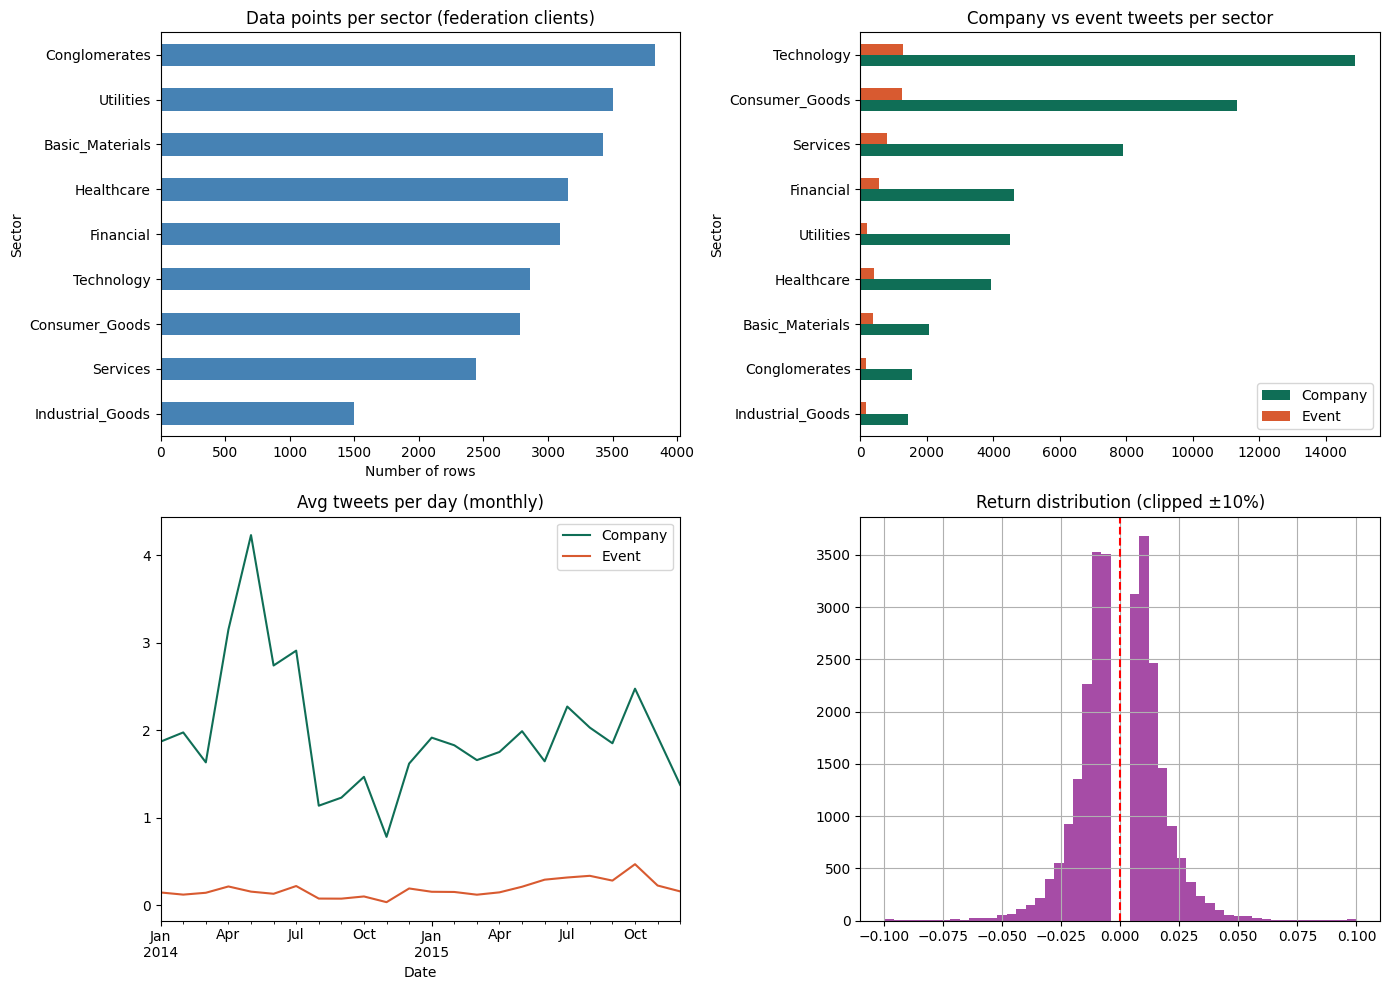

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Rows per sector
clf_df.groupby('Sector').size().sort_values().plot.barh(ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Data points per sector (federation clients)')
axes[0,0].set_xlabel('Number of rows')

# 2. Company vs Event tweet split
tweet_by_sector = clf_df.groupby('Sector').agg(
    company=('Company_Tweet_Count','sum'),
    event=('Event_Tweet_Count','sum')
)
tweet_by_sector.sort_values('company').plot.barh(
    ax=axes[0,1], color=['#0F6E56','#D85A30']
)
axes[0,1].set_title('Company vs event tweets per sector')
axes[0,1].legend(['Company','Event'])

# 3. Tweet coverage over time
monthly = clf_df.set_index('Date').resample('M').agg(
    company=('Company_Tweet_Count','mean'),
    event=('Event_Tweet_Count','mean')
)
monthly.plot(ax=axes[1,0], color=['#0F6E56','#D85A30'])
axes[1,0].set_title('Avg tweets per day (monthly)')
axes[1,0].legend(['Company','Event'])

# 4. Return distribution
clf_df['Return'].clip(-0.1, 0.1).hist(bins=50, ax=axes[1,1], color='purple', alpha=0.7)
axes[1,1].set_title('Return distribution (clipped ±10%)')
axes[1,1].axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('processed_data/eda_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Optional: Save to Google Drive for persistence
# from google.colab import drive
# drive.mount('/content/drive')
# !cp -r processed_data/ /content/drive/MyDrive/MMGTFFF/processed_data/

## Summary

### Output files:
| File | Contents | Use |
|------|----------|-----|
| `stocknet_price_features.csv` | Price + indicators + target + tweet counts | Baseline modeling |
| `company_tweets.parquet` | Company-specific tweet texts per ticker-day | FinBERT → node embeddings |
| `event_tweets.parquet` | Event/global tweet texts per ticker-day | FinBERT → event encoder (edge modifier) |
| `sector_mapping.csv` | Ticker → Sector | Federation client assignment |
| `stocknet_full.parquet` | Everything (master backup) | Reference |

### Next notebook:
1. FinBERT encoding (two passes: company embeddings + event embeddings)
2. SEC EDGAR 10-K/10-Q integration
3. Graph construction
4. Federated partitioning